ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

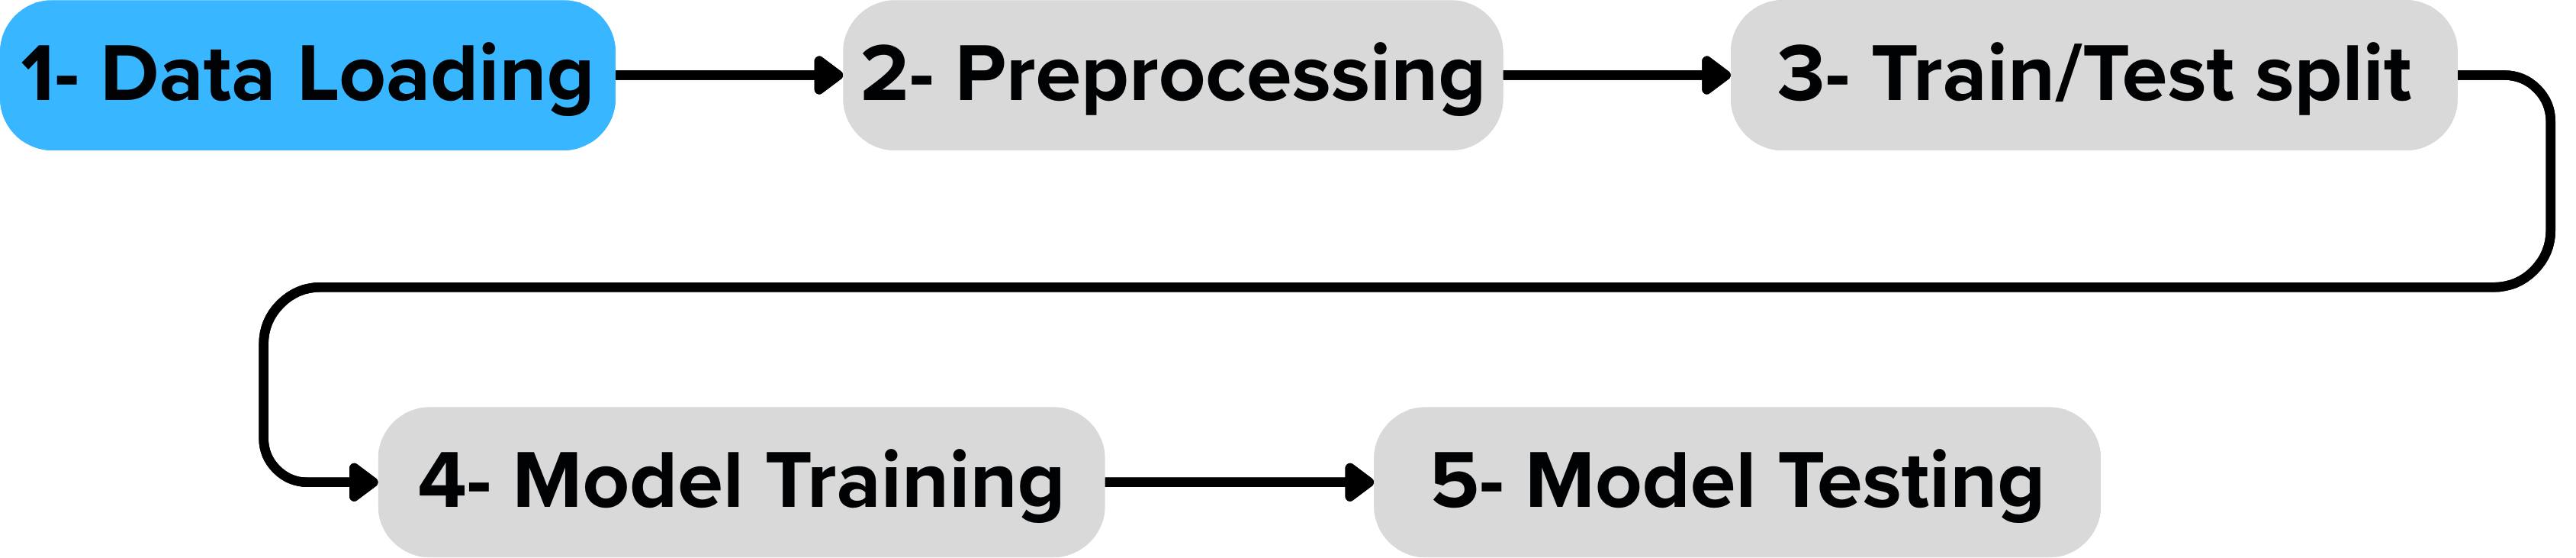

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset
df = pd.read_csv("diabetes_data_upload.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


### Check Missing Values

In [3]:
# Check all values
print(df.isna())

       Age  Gender  Polyuria  Polydipsia  sudden weight loss  weakness  \
0    False   False     False       False               False     False   
1    False   False     False       False               False     False   
2    False   False     False       False               False     False   
3    False   False     False       False               False     False   
4    False   False     False       False               False     False   
..     ...     ...       ...         ...                 ...       ...   
515  False   False     False       False               False     False   
516  False   False     False       False               False     False   
517  False   False     False       False               False     False   
518  False   False     False       False               False     False   
519  False   False     False       False               False     False   

     Polyphagia  Genital thrush  visual blurring  Itching  Irritability  \
0         False           False     

- Used df.isna() to check for missing values
- Purpose: ensure data completeness
- Result: no missing values found

In [4]:
df.isin(["?", "NA", " "]).sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

- Checked for "?", "NA", and empty spaces
- Purpose: detect hidden invalid values
- Result: no incorrect or empty values found

### Check duplicate rows

In [5]:
# checking duplicate rows
df.duplicated().sum()

np.int64(269)

- Used df.duplicated() to check duplicate rows  
- 269 duplicate rows were found  
-  This step helps identify repeated records in the dataset  

In [6]:
df[df.duplicated()]

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
84,35,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,No,No,Positive
159,38,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Positive
160,28,Female,No,No,No,No,No,No,Yes,No,No,No,Yes,Yes,No,No,Positive
161,68,Female,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,No,Positive
162,35,Female,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,53,Male,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,Yes,Yes,No,Negative
497,47,Male,No,No,No,No,No,No,No,No,Yes,No,Yes,No,No,Yes,Negative
498,68,Female,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,No,Positive
499,64,Male,No,No,No,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Negative


- Displayed duplicate rows using `df[df.duplicated()]`  
- This helps identify duplicate records and their positions in the dataset  

### No. of rows and columns

In [7]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (520, 17) 

number of rows:  520
number of columns:  17


### Handling Duplicate Values

In [8]:
df = df.drop_duplicates()

- Removed duplicate rows using `drop_duplicates()`  
- Purpose: to improve data quality and avoid bias in analysis  

### Dataset Shape After Removing Duplicates

In [9]:
# finding number of rows and columns after handling Duplicate

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (251, 17) 

number of rows:  251
number of columns:  17


In [10]:
df.duplicated().sum()

np.int64(0)

- The dataset size changed from 520 to 251 rows  
- Number of columns remained 17  
- No duplicate rows remain  

### Data type of columns

In [11]:
# viewing the data types of columns
df.dtypes

Age                    int64
Gender                object
Polyuria              object
Polydipsia            object
sudden weight loss    object
weakness              object
Polyphagia            object
Genital thrush        object
visual blurring       object
Itching               object
Irritability          object
delayed healing       object
partial paresis       object
muscle stiffness      object
Alopecia              object
Obesity               object
class                 object
dtype: object

- Used `df.dtypes` to check the data types of each column  
- Most columns are categorical (object) representing Yes/No values  
- Age is numeric (int64), which is correct  
- No data type issues or incorrect formats were found  

In [12]:
# Statistical summary
df.describe(include='all')

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,251.000000,251,251,251,251,251,251,251,251,251,251,251,251,251,251,251,251
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,Male,Yes,No,No,Yes,No,No,No,Yes,No,No,No,No,No,No,Positive
freq,NaN,160,132,127,147,159,134,184,140,127,180,126,139,153,161,207,173
mean,48.864542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.526036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,58.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Used `df.describe(include='all')` to summarize the dataset  
- The dataset contains 251 records for all features  
- Most columns are categorical with two unique values (Yes/No)  
- Age ranges from 16 to 90 years with an average around 48  
- No abnormal or unrealistic values were observed  

### Descriptive summary Statistics

### Univariate Analysis

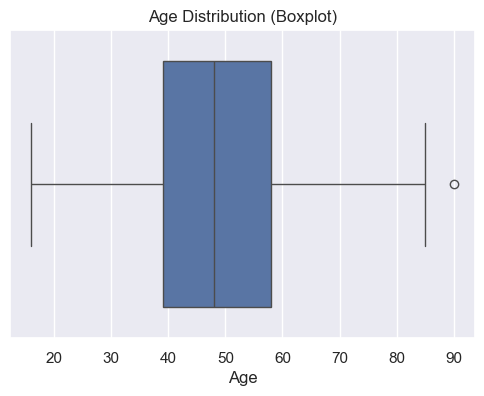

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Age Distribution (Boxplot)")
plt.show()

- This plot was chosen to show the distribution of age in the dataset  

- Most individuals are between 30 and 60 years old  
- The data is concentrated in the middle-age range  

- A clear pattern is observed where values cluster in the middle  
- There is a decreasing trend toward younger and older ages  

### distribution of classes

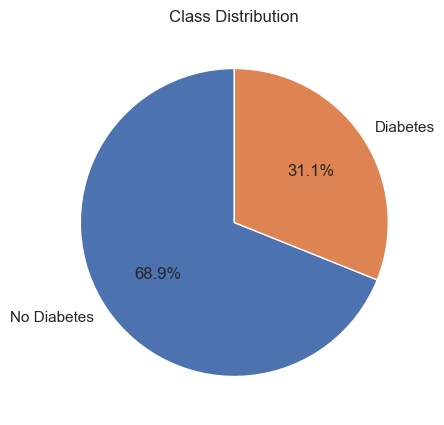

In [ ]:
plt.figure(figsize=(5,5))

df['class'].value_counts().plot.pie(
    labels=['No Diabetes', 'Diabetes'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Class Distribution')
plt.ylabel('')  
plt.show()

- This plot was chosen to show the distribution of the target variable (class)  

- The dataset contains more positive cases than negative cases  
- This indicates that the dataset is imbalanced  

- A clear pattern is observed where positive cases dominate the dataset  
- There is a noticeable difference between the two classes  

- This imbalance may affect analysis and should be considered  

## Bivariate Analysis

### Age Distribution by Diabetes Class

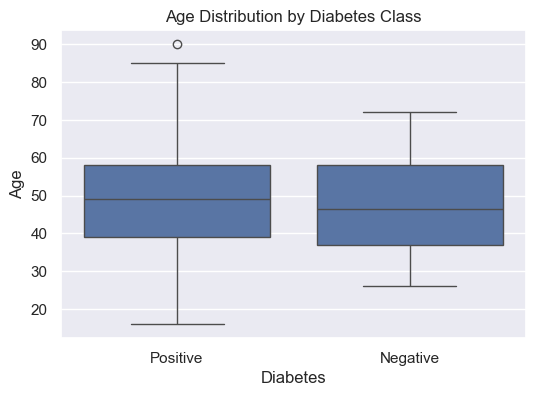

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='class', y='Age', data=df)
plt.title("Age Distribution by Diabetes Class")
plt.xlabel("Diabetes")
plt.ylabel("Age")
plt.show()



- This visualization was chosen to clearly show the distribution of age and detect any outliers in the dataset.
- The boxplot provides a summary of the data including the median, quartiles, and spread of age values.
- Most individuals are between 30 and 60 years old, indicating that the dataset is concentrated in the middle-age group.
- A few higher values can be observed, suggesting the presence of potential outliers.
- This pattern indicates that age is not evenly distributed and is more centered around middle-aged individuals.
- From this, we can learn that middle-aged people are more represented in the dataset, which may influence the model’s predictions.

### Countplot Analysis

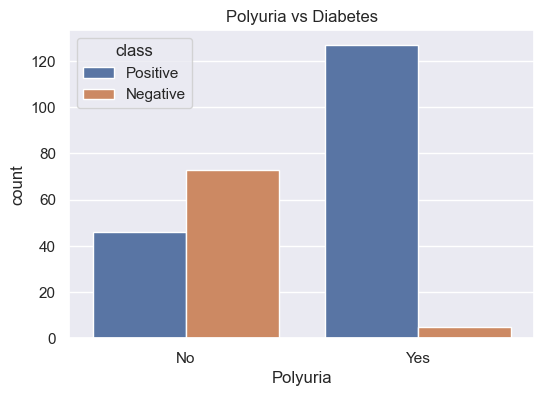

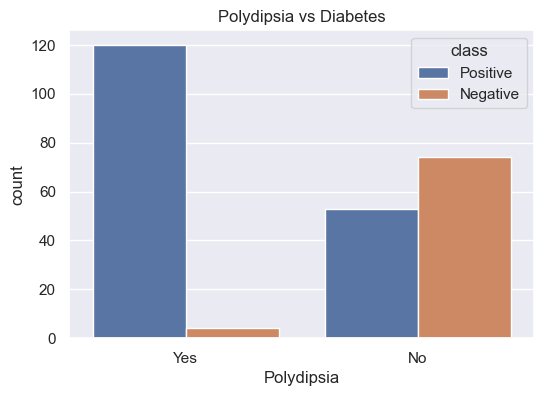

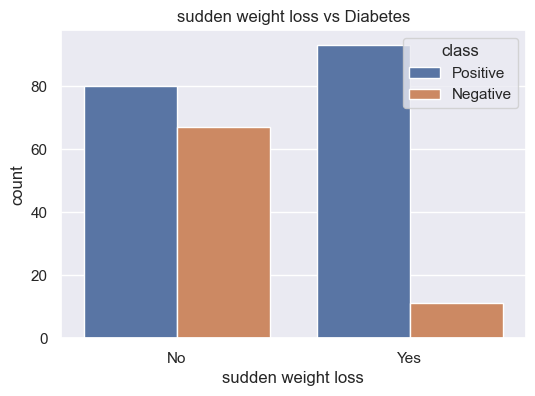

In [28]:
features = ['Polyuria', 'Polydipsia', 'sudden weight loss']

for col in features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f'{col} vs Diabetes')
    plt.show()


- This visualization was used to compare categorical features with the diabetes outcome.
- The countplot shows the frequency of each category (Yes/No) for diabetic and non-diabetic individuals.
- Some features, such as Polyuria and Polydipsia, show a clear difference between the two classes.
- This indicates that these symptoms are strongly associated with diabetes.
- The visualization helps identify important features for prediction.

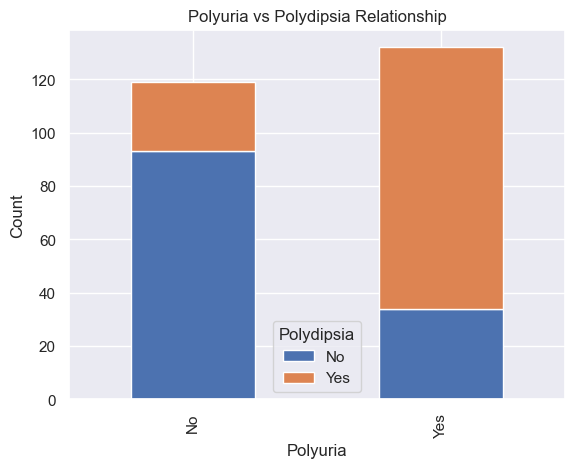

In [17]:
pd.crosstab(df['Polyuria'], df['Polydipsia']).plot(kind='bar', stacked=True)
plt.title("Polyuria vs Polydipsia Relationship")
plt.xlabel("Polyuria")
plt.ylabel("Count")
plt.show()

- This plot was chosen to analyze the relationship between Polyuria and Polydipsia
- It shows how frequently the two symptoms occur together
- A clear pattern is observed where patients with Polyuria are more likely to also have Polydipsia
- Similarly, patients without Polyuria tend not to have Polydipsia
- This indicates a strong association between the two symptoms
- The co-occurrence of these symptoms may be important in identifying diabetic patients
- This analysis provides deeper insight into symptom relationships beyond individual analysis


### Correlation Matrix

In [18]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].map({'Yes':1, 'No':0, 'Positive':1, 'Negative':0, 'Male':1, 'Female':0})

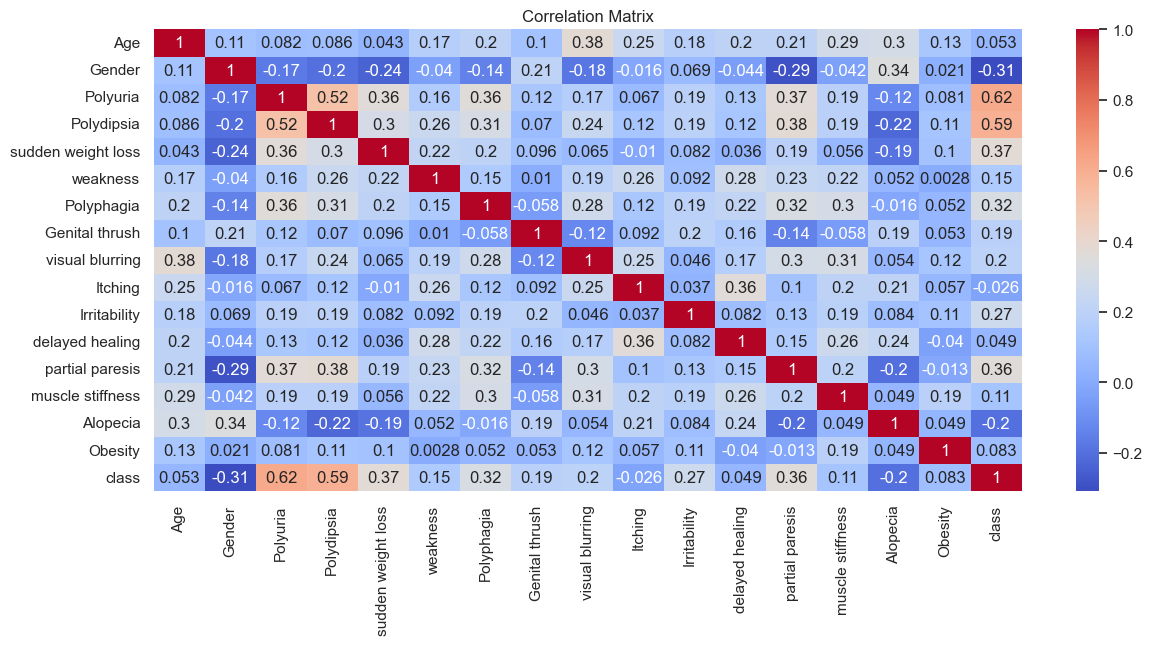

In [24]:
plt.figure(figsize=(14,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- This plot was chosen to analyze the relationships between multiple variables in the dataset
- It shows the correlation between all features and the target class
- Strong positive correlations are observed between Polyuria, Polydipsia, and diabetes
- This indicates that these symptoms are strong predictors of diabetes
- Age shows a very weak correlation with the target class
- This highlights that medical symptoms are more important than demographic features
- The heatmap provides a comprehensive overview of feature relationships

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook
